# 12 練習問題 解答 — 能動循環
対象: [`notebooks/12_active_cycling.ipynb`](../notebooks/12_active_cycling.ipynb)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species
RH,RHC,CH,Rf,C,H = (Species(x) for x in ['RH','RHC','CH','R','C','H'])
K_I,K_DC=0.005,1.0; SP=['RH','RHC','CH','R','C','H']
def R(a,b,k): return ReactionRule(a,b,k)
def build(k_rear=0.5, k_ass=0.02):
    mdl=NetworkModel()
    for x in [R([RH],[Rf,H],K_I),R([RH,C],[RHC],k_ass),R([RHC],[RH,C],K_DC),R([RHC],[CH,Rf],k_rear)]:
        mdl.add_reaction_rule(x)
    return mdl
def halflife(c0, **kw):
    a=run_simulation(300.,y0={'RH':1.,'C':float(c0)},model=build(**kw),solver='ode',ndiv=6000,species_list=SP).as_array()
    t=a[:,0]; res=a[:,1]+a[:,2]; idx=np.where(res<=0.5)[0]
    if len(idx)==0: return np.nan
    i=idx[0]; return t[0] if i==0 else t[i-1]+(0.5-res[i-1])*(t[i]-t[i-1])/(res[i]-res[i-1])

## Q1. `K_REAR`（置換律速）を変えると飽和値・応答が分オーダーになる競合濃度は?

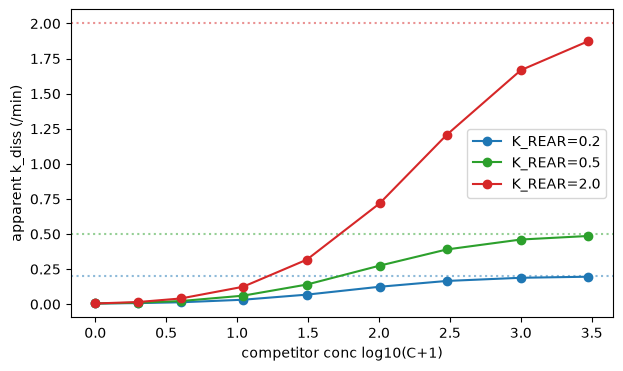

In [2]:
c_grid=np.array([0,1,3,10,30,100,300,1000,3000],float); fig,ax=plt.subplots(figsize=(7,4))
for krear,c in [(0.2,'C0'),(0.5,'C2'),(2.0,'C3')]:
    k=[np.log(2)/halflife(x,k_rear=krear) for x in c_grid]; ax.plot(np.log10(c_grid+1),k,'o-',color=c,label=f'K_REAR={krear}')
    ax.axhline(krear,ls=':',c=c,alpha=.5)
ax.set_xlabel('competitor conc log10(C+1)'); ax.set_ylabel('apparent k_diss (/min)'); ax.legend(); plt.show()

**答**: 見かけ解離速度の**飽和値は $K_{REAR}$ そのもの**（点線）。$K_{REAR}$ を上げると飽和値が上がり、より高い解離速度＝短い半減期に到達できる。また飽和に達する（＝応答が分オーダーになる）競合濃度は、$K_{REAR}$ が大きいほど**低い競合濃度**で足りる。置換ステップの速さが、循環の上限と「必要な競合量」の両方を決める。

## Q2. 良い競合者 / 悪い競合者（`K_ASS` 大/小）

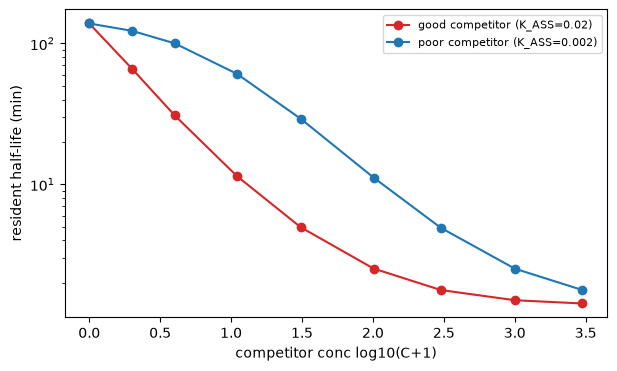

In [3]:
fig,ax=plt.subplots(figsize=(7,4))
for kass,c,lab in [(0.02,'C3','good competitor (K_ASS=0.02)'),(0.002,'C0','poor competitor (K_ASS=0.002)')]:
    hl=[halflife(x,k_ass=kass) for x in c_grid]; ax.plot(np.log10(c_grid+1),hl,'o-',color=c,label=lab)
ax.set_xlabel('competitor conc log10(C+1)'); ax.set_ylabel('resident half-life (min)'); ax.set_yscale('log'); ax.legend(fontsize=8); plt.show()

**答**: **良い競合者**（K_ASS 大）は少ない濃度でも滞在 RNA を速く追い出す（半減期が急落）。**悪い競合者**（K_ASS 小、論文の IstR-1 のような poor Hfq binder）は同じ濃度でもなかなか外せない（半減期が長いまま）。競合者ごとに「外す力」が違う、という論文の観察を再現。

## Q3.（考察）cycling を 07 の set-point モデルに組み込むと?

**答（考察）**: 07 の set-point は、高 Hfq で RNA が singly-bound 複合体に囚われて起きる。cycling（能動交換）を入れると、囚われた RNA が競合 RNA によって外され再分配されるので、**隔離が緩和されて高 Hfq 側の抑制が浅くなり、set-point の窓が広がる**と予測できる（06 で見た「解離が窓を広げる」効果の、より機構的な版）。定量は cycling 反応を 07 モデルに追加して掃引すれば確認できる。

## Q4.（考察）bio-a: 循環は rim / C 末端テールが担う

**答（考察）**: 11 Q4 と同じ軸。循環速度（K_REAR・K_ASS が表す置換のしやすさ）は rim と C 末端テールに依存し、bio-e 01_features では γ-proteo で保存・Firmicutes で欠落。よって **γ-proteo は循環が速く低競合濃度で応答、Firmicutes は循環が遅い**と予測。テール長・rim 保存が「循環の速さ＝応答性」の系統差を測る指標になる（bio-e で定量）。